## Deep Learning

### Chapter 17: Audio Classsification

Original Data: https://huggingface.co/datasets/PolyAI/minds14

A simple audio classification pipeline using the Hugging Face `datasets` library, `librosa` for audio feature extraction (Mel-spectrograms), and `TensorFlow Keras` for building and training a convolutional neural network (CNN).

The goal is to classify spoken intent from short audio snippets using the PolyAI/minds14 dataset. We will cover loading the dataset, preprocessing audio into Mel-spectrograms, building a basic CNN model, and training it for audio classification.

### 0. Load the dataset

In [16]:
from datasets import load_dataset

# Load the minds14 dataset (only has a 'train' split by default)
raw_ds = load_dataset("PolyAI/minds14", "all", split="train")

# Split into train and test sets (e.g., 80% train, 20% test)
split_ds = raw_ds.train_test_split(test_size=0.2, seed=42)

# Limit both sets to at most 1000 samples
ds = {}
ds["train"] = split_ds["train"].select(range(min(len(split_ds["train"]), 1000)))
ds["test"] = split_ds["test"].select(range(min(len(split_ds["test"]), 1000)))

### Import other required libraries

In [17]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# For the model
from tensorflow import keras
from tensorflow.keras import layers

**Drawing the Waveform**

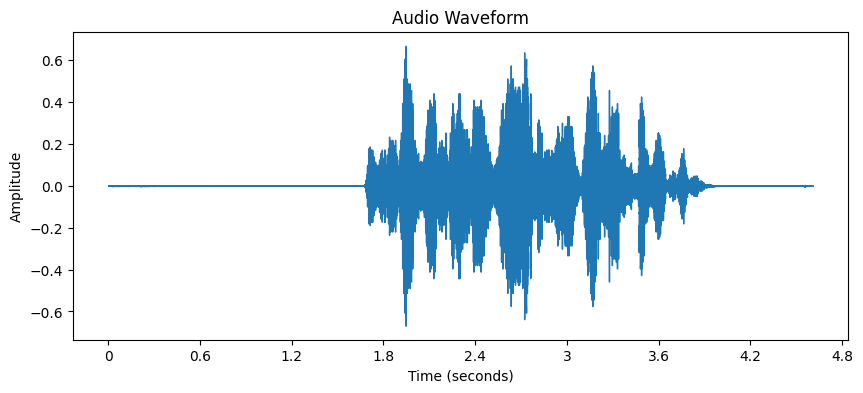

In [18]:
# Take the first sample of the dataset
sample = ds["train"][0]

# Load the audio array and sample rate from the sample dictionary
audio = sample["audio"]["array"]
sample_rate = sample["audio"]["sampling_rate"]

plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sample_rate)

plt.title("Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

**Drawing the Mel-Spectrogram**

In [19]:
mel_spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sample_rate,
    n_mels=128)

mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max)

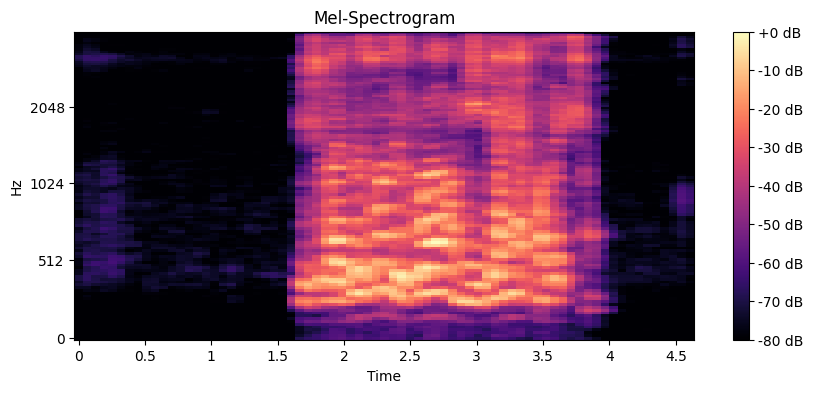

In [20]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mel_db,
    sr=sample_rate,
    x_axis="time",
    y_axis="mel")

plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogram")
plt.show()

**Preprocess the audio data by calculating the mel-spectrogram for each sample in the dataset and storing it as a new column.**

The `preprocess_function` is crucial for preparing the audio data for our deep learning model. Here's a breakdown of its steps and why each is important:

1.  **Extract Audio Array and Sampling Rate:** It retrieves the raw audio data (`audio_array`) and its associated `sampling_rate` from the dataset `example` object.
2.  **Compute Mel-Spectrogram (`librosa.feature.melspectrogram`):**
    *   This converts the raw audio signal into a Mel-spectrogram. A Mel-spectrogram is a visual representation of the spectrum of frequencies in a sound as it varies with time. The Mel scale is a perceptual scale of pitches judged by listeners to be equal in distance from one another. This transformation mimics how the human ear perceives sound, making the features more relevant for audio classification tasks.
    *   `n_mels=128` specifies the number of Mel bands (frequency bins), which determines the height of our spectrogram image. A higher number captures more detail.
3.  **Convert to Decibels (`librosa.power_to_db`):**
    *   The power spectrogram is converted to a decibel (dB) scale. This is important because human hearing perceives sound loudness logarithmically. Converting to dB compresses the wide dynamic range of audio power values, making the features more suitable for neural networks, which often perform better with smaller, normalized input ranges.
4.  **Ensure Consistent Shape (Truncation/Padding):**
    *   Deep learning models, especially CNNs, typically require fixed-size input tensors. Audio samples often vary in length, resulting in spectrograms of different widths (time frames).
    *   `target_frames = 128` sets a desired width for the spectrogram. If a spectrogram is longer than 128 frames, it's truncated; if shorter, it's padded with zeros. This ensures all input spectrograms have a uniform `(128, 128)` shape.
5.  **Add Channel Dimension:**
    *   The Mel-spectrogram is a 2D array. Convolutional Neural Networks (CNNs) usually expect input in `(height, width, channels)` format. For a single-channel (grayscale-like) spectrogram, we add a third dimension of size 1 using `np.newaxis`, resulting in a shape of `(128, 128, 1)`.
6.  **Return Processed Spectrogram and Intent Class:** The function returns the prepared Mel-spectrogram (as `float32` for model compatibility) and the corresponding `intent_class` label.

This preprocessing pipeline transforms raw, variable-length audio signals into consistent, perceptually relevant, and numerically stable 2D image-like representations that are ready to be fed into our Convolutional Neural Network for classification.

In [22]:
def preprocess_function(example):
    audio_array = example["audio"]["array"]
    sampling_rate = example["audio"]["sampling_rate"]

    # Compute Mel-spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(
        y=audio_array,
        sr=sampling_rate,
        n_mels=128
    )

    # Convert to decibels
    mel_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # Ensure consistent shape (128, 128) for the spectrogram
    # The input_shape for the model is (128, 128, 1), so we target 128 time frames.
    target_frames = 128
    current_frames = mel_db.shape[1]

    if current_frames > target_frames:
        # Truncate if too long
        mel_db = mel_db[:, :target_frames]
    elif current_frames < target_frames:
        # Pad with zeros if too short
        padding = np.zeros((mel_db.shape[0], target_frames - current_frames))
        mel_db = np.concatenate((mel_db, padding), axis=1)

    # Add a channel dimension for the Conv2D layer (128, 128, 1)
    mel_db = mel_db[..., np.newaxis]

    # Return the processed spectrogram and the intent class
    return {"mel_spectrogram": mel_db.astype(np.float32),
            "intent_class": example["intent_class"]}

# Apply the preprocessing function to each dataset split individually
processed_ds = {}
for split in ["train", "test"]:
    processed_ds[split] = ds[split].map(
        preprocess_function,
        remove_columns=["audio", "path", "transcription", "english_transcription", "lang_id"],
        batched=False # Process one example at a time
    )

# Limit to 5 labels for demonstration
# Get unique intent classes from the training set and take the first 5
unique_labels_train = np.unique(processed_ds["train"]["intent_class"])
selected_labels = unique_labels_train[:5]

# Filter datasets to include only these selected labels
processed_ds["train"] = processed_ds["train"].filter(lambda x: x["intent_class"] in selected_labels)
processed_ds["test"] = processed_ds["test"].filter(lambda x: x["intent_class"] in selected_labels)

# Prepare the final numpy arrays for modeling
X_train = np.array(processed_ds["train"]["mel_spectrogram"])
y_train = np.array(processed_ds["train"]["intent_class"])
X_test = np.array(processed_ds["test"]["mel_spectrogram"])
y_test = np.array(processed_ds["test"]["intent_class"])

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

**Building a Simple Audio Classification Model**

In [23]:
# The input shape for the model. It represents (height, width, channels) of the Mel-spectrogram.
# 128: Number of Mel bands (from librosa.feature.melspectrogram's n_mels).
# 128: Number of time frames (a common choice for fixed-size input).
# 1: Single channel as it's a grayscale-like image of the spectrogram.
input_shape = (128, 128, 1)
# The number of output classes for the classification model.
# This corresponds to the 5 selected intent classes.
num_classes = 5

model = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,605 (14.14 MB)

 Trainable params: 3,705,605 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 790ms/step - accuracy: 0.2101 - loss: 57.6254 - val_accuracy: 0.2044 - val_loss: 1.7785
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 695ms/step - accuracy: 0.2819 - loss: 1.5960 - val_accuracy: 0.2779 - val_loss: 1.6236
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 697ms/step - accuracy: 0.3910 - loss: 1.4904 - val_accuracy: 0.2698 - val_loss: 1.7247
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 688ms/step - accuracy: 0.4069 - loss: 1.3583 - val_accuracy: 0.2452 - val_loss: 1.7840
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 681ms/step - accuracy: 0.5239 - loss: 1.2153 - val_accuracy: 0.2125 - val_loss: 1.9673
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 679ms/step - accuracy: 0.6090 - loss: 1.0441 - val_accuracy: 0.2289 - val_loss: 1.9785
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 666ms/step - accuracy: 0.7101 - loss: 0.8441 - val_accuracy: 0.2752 - val_loss: 2.2261
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7420 - loss: 0.6669 - val_accuracy: 0

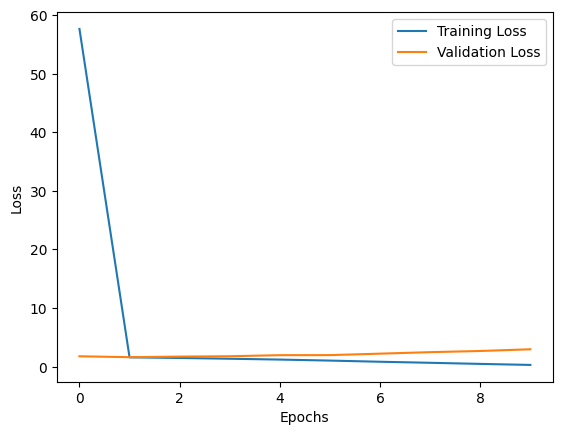

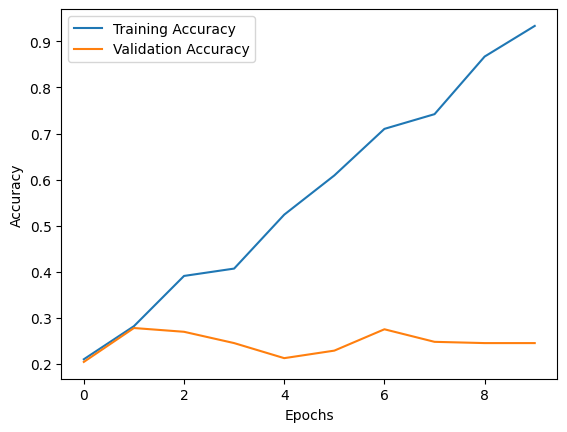

In [26]:
# Plot loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot Accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
new_spectrogram = np.expand_dims(mel_db, axis=0)
prediction = model.predict(new_spectrogram)

predicted_class = prediction.argmax(axis=1)[0]
actual_class =

print("Predicted class:", predicted_class)